In [ ]:
pip install hmmlearn

In [ ]:
pip install pymongo pandas

In [3]:
pip install pymongo certifi

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import certifi
from sklearn.decomposition import PCA
from hmmlearn.vhmm import VariationalGaussianHMM
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Query the data

In [5]:
def query_mongodb(uri="blured", collection_name="vix_data", db_name="DB_VIX", filtro=None):
    client = MongoClient(uri, tls=True, tlsCAFile=certifi.where())

    db = client[db_name]
    collection = db[collection_name]

    filtro = filtro or {}

    # bring data
    docs = list(collection.find(filtro))

    if not docs:
        return pd.DataFrame()

    df = pd.DataFrame(docs)

    # transform _id to datetime
    if "_id" in df.columns:
        df["_id"] = pd.to_datetime(df["_id"])
        df.set_index("_id", inplace=True)

    return df

In [7]:
data =query_mongodb()
data.tail()

,DXY_overnight,Drawdown,GOLD_overnight,IV_RV_Ratio,Intraday_VIX_Move,Momentum_1M,Momentum_3M,Momentum_6M,OIL_overnight,Open_DXY,...,VIX_Percentile,VIX_RV_Spread,VIX_STD_10,VIX_STD_5,VIX_Trend,VIX_Vol_10d,VIX_Vol_21d,VIX_Vol_5d,VIX_Zscore,VIX_Zscore_Sq
_id,,,,,,,,,,,,,,,,,,,,,
2026-04-24,0.002038,-0.004133,0.000870,108.001103,0,0.078354,0.022758,0.031610,0.040043,98.820999,...,0.720238,19.131205,0.667350,0.792231,-0.328597,0.035686,0.074094,0.045233,-0.614410,0.377500
2026-04-27,0.005181,0.000000,0.003855,115.536541,0,0.106207,0.026722,0.050238,-0.010557,99.332001,...,0.674603,18.548059,0.640309,0.329500,-0.447406,0.036825,0.071026,0.046519,-0.709299,0.503105
2026-04-28,-0.008688,0.000000,-0.002145,126.398015,1,0.126406,0.028071,0.048787,0.011192,98.467003,...,0.613095,17.877435,0.642786,0.578507,-0.591933,0.038444,0.062595,0.033045,-0.911075,0.830058
2026-04-29,0.001401,-0.004894,-0.014848,124.327745,1,0.125333,0.024364,0.041861,0.031447,98.608002,...,0.585317,17.686589,0.679007,0.620298,-0.728869,0.036598,0.062627,0.023509,-0.898999,0.808200
2026-04-30,0.002444,-0.005291,-0.009046,161.427481,2,0.093043,0.028379,0.053813,0.093872,98.850998,...,0.682540,18.693477,0.677224,0.606036,-0.788929,0.040616,0.054333,0.038343,-0.453291,0.205473


In [8]:
data["Intraday_VIX_Move"]. value_counts()

,count
Intraday_VIX_Move,
1,1710
0,1633
2,1629


## Walk-forward expanding window

In [ ]:
# 1. CLEAN AND SCALE FUNCTION
def clean_features(X):
    """
    Handle missing values and infinite values.
    """
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.ffill().fillna(0)
    return X.astype(np.float64)


# 1.1 PCA PIPELINE
def build_pipeline_pca(n_components=14):
    """
    PCA preprocessing pipeline with scaling and cleaning.
    """
    return Pipeline([
        ("clean", FunctionTransformer(clean_features)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components))
    ])

def walk_forward_rolling(data, train_size=500, years=13, test_size=500):

    """
    Rolling window forecasting with:
    - First train = 13 years
    - Fixed rolling window = 500
    - Train + Val split (1-step ahead)
    - Final hold-out test set
    """

    X = data.drop(columns=["Intraday_VIX_Move"]).copy()
    y = data["Intraday_VIX_Move"].astype(float)
    y.index = pd.RangeIndex(len(y))

    all_splits = []

    # INITIAL TRAIN
    initial_train = years * 252

    # WALK-FORWARD SPLITS
    for i in range(initial_train, len(data) - test_size):

        start_train = max(0, i - train_size)

        X_train = X.iloc[start_train:i]
        y_train = y.iloc[start_train:i]

        X_val = X.iloc[i:i+1]
        y_val = y.iloc[i:i+1]

        # Clean
        X_train = clean_features(X_train)
        X_val = clean_features(X_val)

        # PCA
        pipeline = build_pipeline_pca(n_components=14)

        X_train_transformed = pipeline.fit_transform(X_train)
        X_val_transformed = pipeline.transform(X_val)

        n_comp = X_train_transformed.shape[1]

        X_train_final = pd.DataFrame(
            X_train_transformed,
            index=X_train.index,
            columns=[f"PC{i+1}" for i in range(n_comp)]
        )

        X_val_final = pd.DataFrame(
            X_val_transformed,
            index=X_val.index,
            columns=[f"PC{i+1}" for i in range(n_comp)]
        )
        all_splits.append((X_train_final, X_val_final, y_train, y_val))

    # FINAL TEST SET (HOLD-OUT)
    test_start = len(data) - test_size

    X_test = clean_features(X.iloc[test_start:])
    y_test = y.iloc[test_start:]

    pipeline = build_pipeline_pca(n_components=14)

    X_train_full = clean_features(X.iloc[:test_start])
    pipeline.fit(X_train_full)

    X_test_final = pd.DataFrame(
        pipeline.transform(X_test),
        index=X_test.index
    )

    return all_splits, (X_test_final, y_test)

In [ ]:
splits, test_set = walk_forward_rolling(
    data,
    train_size=500,
    years=13,
    test_size=500
)

# PRINT SPLITS INFO (TRAIN / VAL)
for i, (X_train, X_val, y_train, y_val) in enumerate(splits[:3]):

    print(f"Split {i+1}")

    print("Train size:", len(X_train), "/ Val size:", len(X_val))
    print("Train From:", X_train.index[0], "to", X_train.index[-1])
    print("Val Date:", X_val.index[0])

    print("-" * 50)

# PRINT TEST INFO
X_test, y_test = test_set

print("\nFINAL TEST SET")
print("Test size:", len(X_test))
print("Test From:", X_test.index[0], "to", X_test.index[-1])

Split 1
Train size: 500 / Val size: 1
Train From: 2017-11-30 00:00:00 to 2019-10-30 00:00:00
Val Date: 2019-10-31 00:00:00
--------------------------------------------------
Split 2
Train size: 500 / Val size: 1
Train From: 2017-12-01 00:00:00 to 2019-10-31 00:00:00
Val Date: 2019-11-01 00:00:00
--------------------------------------------------
Split 3
Train size: 500 / Val size: 1
Train From: 2017-12-04 00:00:00 to 2019-11-01 00:00:00
Val Date: 2019-11-04 00:00:00
--------------------------------------------------

FINAL TEST SET
Test size: 500
Test From: 2024-05-20 00:00:00 to 2026-04-17 00:00:00


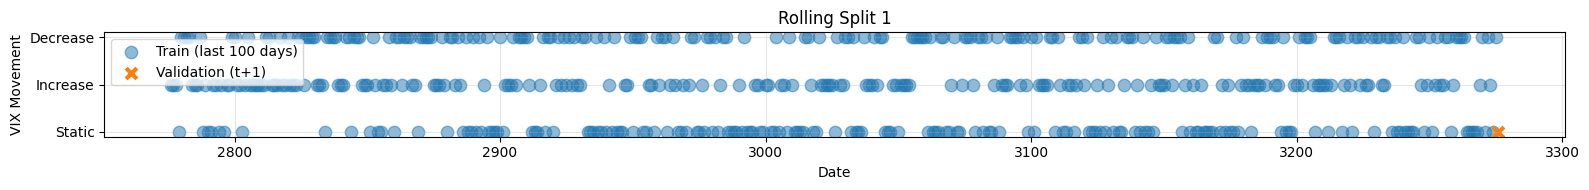

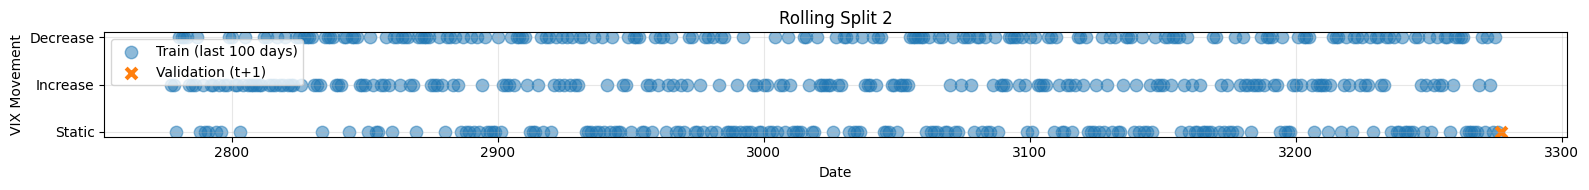

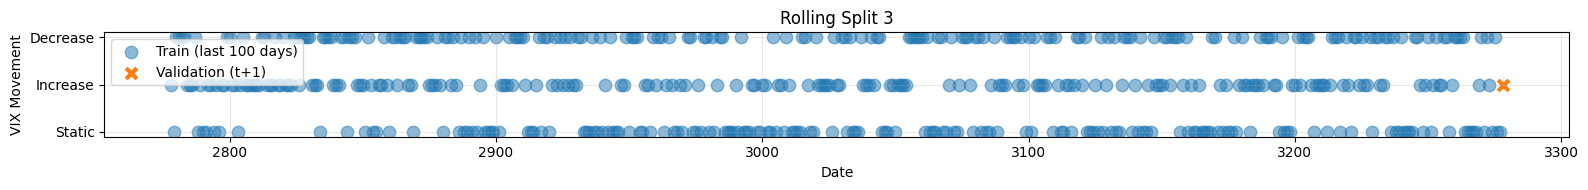

In [ ]:
last_n_days = 500

for i, (X_train, X_val, y_train, y_val) in enumerate(splits[:3]):

    # Last part of training
    y_train_last = y_train.iloc[-last_n_days:]

    # Validation point
    y_val_point = y_val

    # PLOT
    plt.figure(figsize=(16, 2))

    plt.scatter(y_train_last.index, y_train_last,
                label='Train (last 100 days)', s=80, alpha=0.5)

    plt.scatter(y_val_point.index, y_val_point,
                label='Validation (t+1)', s=60, marker='x', linewidths=3)

    plt.xlabel("Date")
    plt.ylabel("VIX Movement")
    plt.yticks([0, 1, 2], ['Static', 'Increase', 'Decrease'])
    plt.title(f"Rolling Split {i+1}")
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Model

In [ ]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# save results
scores = []
pred_real = pd.DataFrame()

# columns used for HMM
hmm_cols = ["PC1", "PC2", "PC3"]
scaler = StandardScaler()

# hyperparameters grid
param_grid = {
    'poly__degree': [1, 2],
    'logreg__C': [35, 50, 75, 90, 100 , 115],
    'logreg__penalty': ['l2'],
    'logreg__solver': ['lbfgs']
}

# LOOP OVER SPLITS (NOW TRAIN / VAL)
for i, (X_train, X_val, Y_train, Y_val) in enumerate(splits):

    # HMM REGIME DETECTION
    X_train_hmm_scaled = scaler.fit_transform(X_train[hmm_cols])

    hmm = VariationalGaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=1400,
        tol=1e-3,
        random_state=42,
        init_params="stmc",
        params="stmc"
    )

    hmm.fit(X_train_hmm_scaled)

    train_probs = hmm.predict_proba(X_train_hmm_scaled)

    X_val_hmm_scaled = scaler.transform(X_val[hmm_cols])
    val_probs = hmm.predict_proba(X_val_hmm_scaled)

    # ADD HMM FEATURES
    X_train_copy = X_train.copy()
    X_val_copy = X_val.copy()

    for s in range(train_probs.shape[1]):
        X_train_copy[f"hmm_state_{s}"] = train_probs[:, s]
        X_val_copy[f"hmm_state_{s}"] = val_probs[:, s]

    # PIPELINE + GRID SEARCH
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(include_bias=False)),
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(max_iter=1000))
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        scoring='precision_weighted',
        cv=2
    )

    grid.fit(X_train_copy, Y_train)
    best_model = grid.best_estimator_

    # PREDICTIONS (VALIDATION)
    preds_stack = best_model.predict(X_val_copy)

    # STORE RESULTS
    pred_real = pd.concat([
        pred_real,
        pd.DataFrame({
            'pred_class': preds_stack,
            'real_class': Y_val.values.ravel(),
            'residual_class': Y_val.values.ravel() - preds_stack,
            'val_regime': hmm.predict(X_val_hmm_scaled)
        }, index=Y_val.index)
    ])

    # METRICS
    precision = precision_score(
        Y_val,
        preds_stack,
        zero_division=0,
        average="weighted"
    )

    scores.append({
        'split': i + 1,
        'degree': grid.best_params_['poly__degree'],
        'C': grid.best_params_['logreg__C'],
        'precision_weighted': precision
    })

    print(
        f"Split {i+1}/{len(splits)} completed. "
        f"Best degree: {grid.best_params_['poly__degree']}, "
        f"Best C: {grid.best_params_['logreg__C']}"
    )

# FINAL METRICS
metrics_df = pd.DataFrame(scores)
precision_mean = round(metrics_df['precision_weighted'].mean(), 2)

print("Mean precision across models:", precision_mean)

In [ ]:
scores_metrics=pd.DataFrame(scores)
mean_scores = scores_metrics.groupby(['C', 'degree'])['precision_weighted'].mean()
mean_scores

C    degree
35   1         0.403471
     2         0.390533
50   1         0.375000
     2         0.428571
75   1         0.319149
     2         0.383562
90   1         0.647059
     2         0.425000
100  1         0.571429
     2         0.449275
115  1         0.363636
     2         0.415094
Name: precision_weighted, dtype: float64

## Best Model

In [ ]:
pred_real = pd.DataFrame()

hmm_cols = ["PC1", "PC2", "PC3"]

model_lr = LogisticRegression(C=90, max_iter=1400)

for i, (X_train, X_val, Y_train, Y_val) in enumerate(splits):

    # --- SCALER ---
    scaler = StandardScaler()

    X_train_hmm_scaled = scaler.fit_transform(X_train[hmm_cols])
    X_val_hmm_scaled = scaler.transform(X_val[hmm_cols])

    # --- HMM ---
    hmm = VariationalGaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=1400,
        tol=1e-3,
        random_state=42,
        init_params="stmc",
        params="stmc"
    )

    hmm.fit(X_train_hmm_scaled)

    train_probs = hmm.predict_proba(X_train_hmm_scaled)
    val_probs = hmm.predict_proba(X_val_hmm_scaled)

    # --- ADD FEATURES ---
    X_train_copy = X_train.copy()
    X_val_copy = X_val.copy()

    for s in range(train_probs.shape[1]):
        X_train_copy[f"hmm_state_{s}"] = train_probs[:, s]
        X_val_copy[f"hmm_state_{s}"] = val_probs[:, s]

    # --- MODEL ---
    model_lr.fit(X_train_copy, Y_train.values.ravel())

    preds_stack = model_lr.predict(X_val_copy)
    probs_stack = model_lr.predict_proba(X_val_copy)

    # --- SAVE ---
    pred_real = pd.concat([
        pred_real,
        pd.DataFrame({
            'pred_class': preds_stack.ravel(),
            'real_class': Y_val.values.ravel(),
            'residual_class': Y_val.values.ravel() - preds_stack.ravel(),
            'val_regime': hmm.predict(X_val_hmm_scaled),
            'proba_class_0': probs_stack[:, 0],
            'proba_class_1': probs_stack[:, 1],
            'proba_class_2': probs_stack[:, 2],
        }, index=Y_val.index)
    ])

    precision = precision_score(
        Y_val,
        preds_stack,
        zero_division=0,
        average="weighted"
    )

    print(f"Split {i+1}/{len(splits)} completed. Precision: {precision:.4f}")

# FINAL METRIC
precision_mean = round(
    precision_score(pred_real['real_class'], pred_real['pred_class'], average='weighted'),
    4
)

print("Mean precision across all splits:", precision_mean)

## Backtesting

In [9]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def clean_features(X):
    """
    Handle missing values and infinite values.
    """
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.ffill().fillna(0)
    return X.astype(np.float64)


def build_pipeline_pca(n_components=14):
    """
    PCA preprocessing pipeline with scaling and cleaning.
    """
    return Pipeline([
        ("clean", FunctionTransformer(clean_features)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components))
    ])

def backtesting_prod(test_size,model,data):

  pred_real = pd.DataFrame()

  hmm_cols = ["PC1", "PC2", "PC3"]

  # 1. FINAL HOLDOUT SPLIT
  test_start = len(data) - test_size

  X = clean_features(data.drop(columns=["Intraday_VIX_Move"]))
  y = data["Intraday_VIX_Move"].astype(float)

  X_train_full = X.iloc[:test_start]
  y_train_full = y.iloc[:test_start]

  X_test = X.iloc[test_start:]
  y_test = y.iloc[test_start:]

  # 2. PCA (FIT ON TRAIN ONLY)
  pca_pipeline = build_pipeline_pca(n_components=14)
  pca_pipeline.fit(X_train_full)

  X_train_pca = pd.DataFrame(
      pca_pipeline.transform(X_train_full),
      index=X_train_full.index,
      columns=[f"PC{i+1}" for i in range(14)]
  )

  X_test_pca = pd.DataFrame(
      pca_pipeline.transform(X_test),
      index=X_test.index,
      columns=[f"PC{i+1}" for i in range(14)]
  )

  # 3. HMM (FIT ON TRAIN ONLY)
  scaler_hmm = StandardScaler()

  X_train_hmm_scaled = scaler_hmm.fit_transform(X_train_pca[hmm_cols])
  X_test_hmm_scaled = scaler_hmm.transform(X_test_pca[hmm_cols])

  hmm = VariationalGaussianHMM(
      n_components=3,
      covariance_type="full",
      n_iter=1400,
      tol=1e-3,
      random_state=42
  )

  hmm.fit(X_train_hmm_scaled)

  train_probs = hmm.predict_proba(X_train_hmm_scaled)
  test_probs = hmm.predict_proba(X_test_hmm_scaled)

  # 4. ADD HMM FEATURES
  X_train_final = X_train_pca.copy()
  X_test_final = X_test_pca.copy()

  for s in range(train_probs.shape[1]):
      X_train_final[f"hmm_state_{s}"] = train_probs[:, s]
      X_test_final[f"hmm_state_{s}"] = test_probs[:, s]

  # 5. MODEL (PRODUCTION TRAIN)

  model.fit(X_train_final, y_train_full.values.ravel())

  # 6. PREDICTION (HOLDOUT TEST)
  preds = model.predict(X_test_final).ravel()
  probs = model.predict_proba(X_test_final)

  # 7. RESULTS
  pred_real = pd.DataFrame({
      "pred_class": preds,
      "real_class": y_test.values.ravel(),
      "residual_class": y_test.values.ravel() - preds,
      "test_regime": hmm.predict(X_test_hmm_scaled),
      "proba_class_0": probs[:, 0],
      "proba_class_1": probs[:, 1],
      "proba_class_2": probs[:, 2],
  }, index=y_test.index)

  return pred_real

In [10]:
model_lr = LogisticRegression(C=90, max_iter=6000)

In [11]:
test_sizes = [5, 10, 20, 30, 40, 50, 60, 90, 100, 200]

results = []
backtesting_dict = {}

for ts in test_sizes:

    backtesting_res = backtesting_prod(
        test_size=ts,
        model=model_lr,
        data=data
    )

    backtesting_dict[ts] = backtesting_res

    precision = precision_score(
        backtesting_res['real_class'],
        backtesting_res['pred_class'],
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        backtesting_res['real_class'],
        backtesting_res['pred_class'],
        average="weighted"
    )

    results.append({
        "test_size": ts,
        "precision": precision,
        "f1_score": f1
    })

metrics_df = pd.DataFrame(results)
print(metrics_df)

   test_size  precision  f1_score
0          5   0.100000  0.133333
1         10   0.400000  0.384416
2         20   0.344444  0.334266
3         30   0.483333  0.410101
4         40   0.482837  0.336173
5         50   0.556667  0.412673
6         60   0.502547  0.428513
7         90   0.661635  0.485472
8        100   0.528305  0.515854
9        200   0.527920  0.508023


## Evaluate

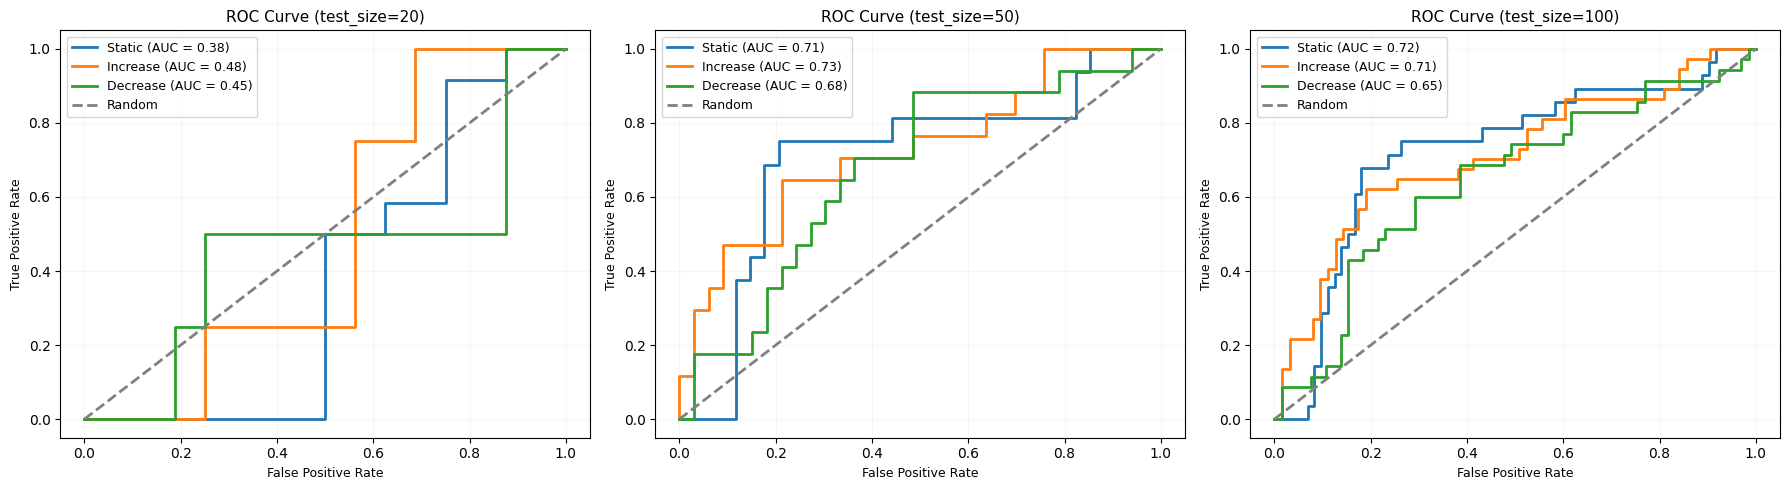

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

backtesting_res_20 = backtesting_dict[20]
backtesting_res_50 = backtesting_dict[50]
backtesting_res_100 = backtesting_dict[100]

classes = [0, 1, 2]
labels = ['Static', 'Increase', 'Decrease']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res, name in zip(
    axes,
    [backtesting_res_20, backtesting_res_50, backtesting_res_100],
    ["20", "50", "100"]
):
    # TRUE LABELS
    y_true = res['real_class'].values
    y_true_bin = label_binarize(y_true, classes=classes)

    # PROBABILITIES
    y_score = np.column_stack([
        res['proba_class_0'].values if 'proba_class_0' in res.columns else None,
        res['proba_class_1'].values,
        res['proba_class_2'].values if 'proba_class_2' in res.columns else None
    ])

    if y_score.shape[1] != len(classes):
        raise ValueError("ROC multiclass requires probability per class")

    # ROC CURVES
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, lw=2,
                label=f'{labels[i]} (AUC = {roc_auc:.2f})')

    # Random baseline
    ax.plot([0, 1], [0, 1],
            color='gray', linestyle='--', lw=2,
            label='Random')

    # STYLE
    ax.set_title(f'ROC Curve (test_size={name})', fontsize=11)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.1)

plt.tight_layout()
plt.show()

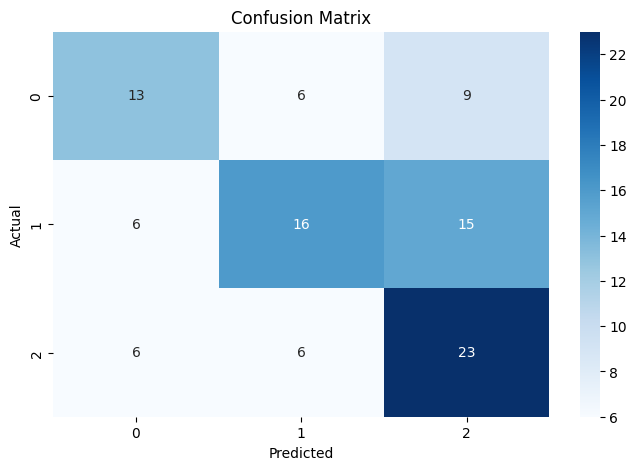

F1 Score:  0.51


In [ ]:
cm = confusion_matrix(backtesting_res_100['real_class'], backtesting_res_100['pred_class'])
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# F1 Score
f1 = f1_score(backtesting_res_100['real_class'], backtesting_res_100['pred_class'], average='macro')
print("F1 Score: ", round(f1, 2))

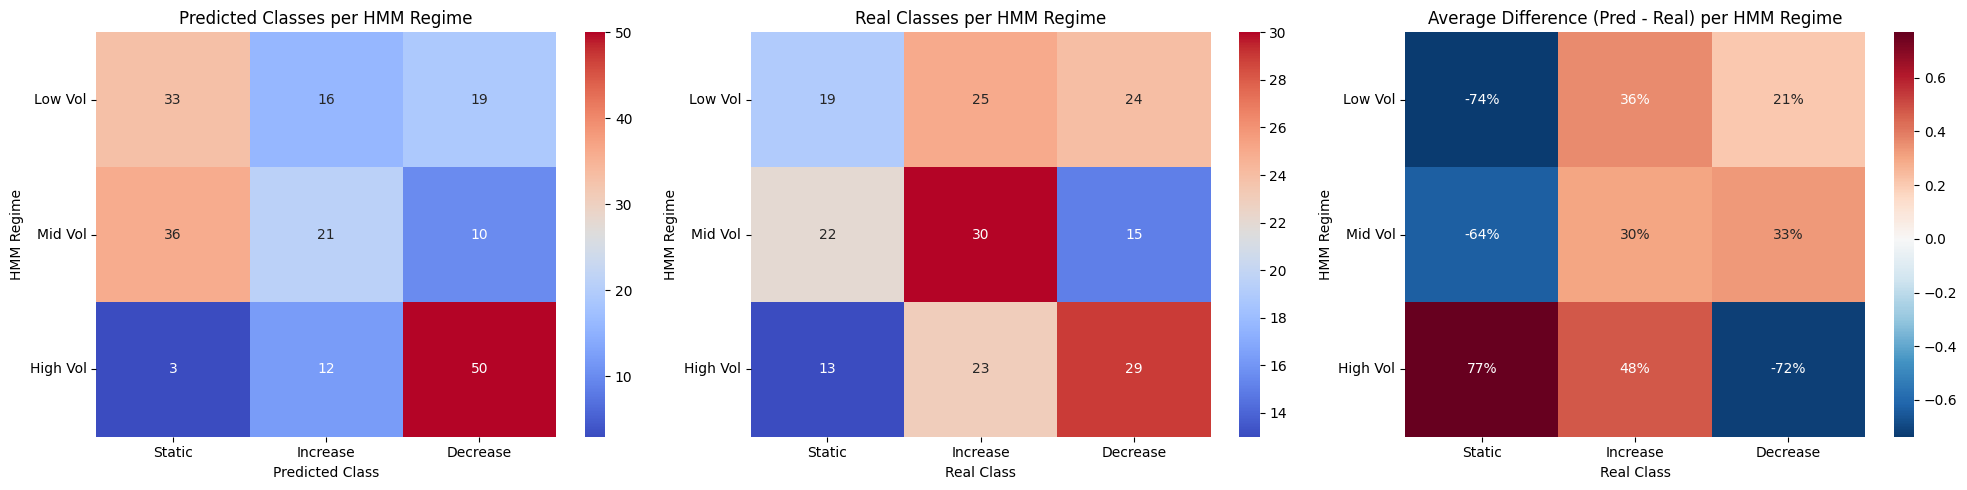

In [ ]:
# Compute difference between predicted and real classes
backtesting_res_200 = backtesting_dict[200]

backtesting_res_200['diff_class'] = backtesting_res_200['pred_class'] - backtesting_res_200['real_class']

# Pivot tables
heat_pred = pd.crosstab(backtesting_res_200['test_regime'], backtesting_res_200['pred_class'])
heat_real = pd.crosstab(backtesting_res_200['test_regime'], backtesting_res_200['real_class'])
heat_diff = (heat_real - heat_pred)/heat_real

# Create figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Heatmap of predictions
sns.heatmap(heat_pred, annot=True, fmt='d', cmap='coolwarm', ax=axes[0])
axes[0].set_xticks([0.5,1.5,2.5])
axes[0].set_xticklabels(["Static", "Increase", "Decrease"], rotation=0)
axes[0].set_yticks([0.5,1.5,2.5])
axes[0].set_yticklabels(['Low Vol','Mid Vol','High Vol'], rotation=0)
axes[0].set_title("Predicted Classes per HMM Regime")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("HMM Regime")

# Heatmap of real classes
sns.heatmap(heat_real, annot=True, fmt='d', cmap='coolwarm', ax=axes[1])
axes[1].set_xticks([0.5,1.5,2.5])
axes[1].set_xticklabels(["Static", "Increase", "Decrease"], rotation=0)
axes[1].set_yticks([0.5,1.5,2.5])
axes[1].set_yticklabels(['Low Vol','Mid Vol','High Vol'], rotation=0)
axes[1].set_title("Real Classes per HMM Regime")
axes[1].set_xlabel("Real Class")
axes[1].set_ylabel("HMM Regime")

# Heatmap of differences (Predicted - Real)
sns.heatmap(heat_diff, annot=True, fmt=".0%", cmap='RdBu_r', center=0, ax=axes[2])
axes[2].set_xticks([0.5,1.5,2.5])
axes[2].set_xticklabels(["Static", "Increase", "Decrease"], rotation=0)
axes[2].set_yticks([0.5,1.5,2.5])
axes[2].set_yticklabels(['Low Vol','Mid Vol','High Vol'], rotation=0)
axes[2].set_title("Average Difference (Pred - Real) per HMM Regime")
axes[2].set_xlabel("Real Class")
axes[2].set_ylabel("HMM Regime")

plt.tight_layout()
plt.show()